In [49]:
"""
Toy Autoregressive Model — Neural Parameterization of Conditionals
===================================================================
Demonstrates TWO cases from the textbook section:

  CASE 1 — Discrete data (categorical + softmax)
    We model 2-word sentences drawn from a tiny vocabulary of 4 words.
    The model learns:
      p(x1)          — which word tends to come first
      p(x2 | x1)     — which word tends to follow, given the first

  CASE 2 — Continuous data (Gaussian parameterization)
    We model 2D points (x1, x2) where x2 depends on x1.
    The model learns:
      p(x1)          — a fixed Gaussian marginal (we skip this for simplicity)
      p(x2 | x1)     — a Gaussian whose mean and variance are
                        predicted by a neural network given x1.

Requirements: pip install torch numpy matplotlib
"""

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


# --- 1. Global Academic Plot Settings ---
plt.rcParams.update({
    'font.family': 'serif',          # Serif font matches LaTeX documents
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.linewidth': 1.2,           # Thicker axes edges
    'xtick.direction': 'in',         # Inward pointing ticks
    'ytick.direction': 'in',
    'xtick.top': True,               # Ticks on top and right axes
    'ytick.right': True,
    'xtick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.major.size': 6,
    'ytick.minor.size': 3,
    'legend.fontsize': 11,
    'legend.frameon': False          # Remove box around legend
})
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### We generate a long sequence and divide  into segments of length T. The true model is 
$$
x_t = 0.7 \cdot x_{t-1} + \epsilon \;\; \epsilon \sim \mathcal{N}(0,1)
$$

In [7]:
def generate_ar1_sequence(n_steps=10000, phi=0.7, sigma=1.0):
    x = np.zeros(n_steps)
    noise = np.random.normal(0, sigma, n_steps)
    for t in range(1, n_steps):
        x[t] = phi * x[t-1] + noise[t]
    return x.astype(np.float32)

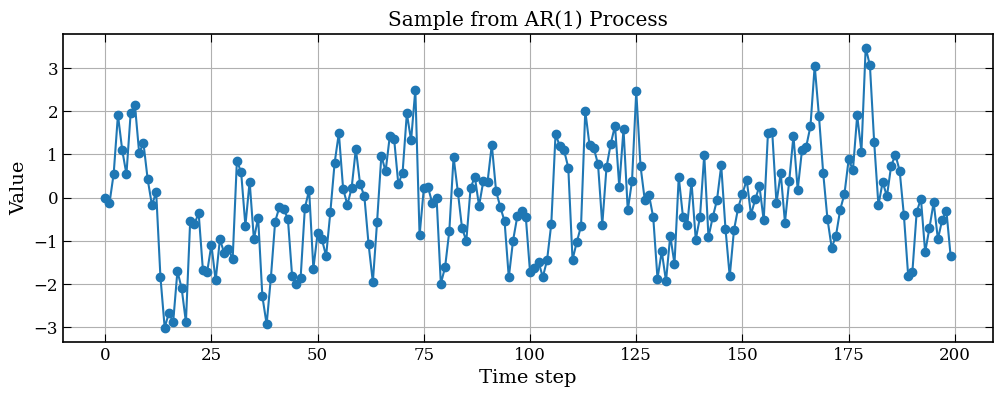

In [50]:
n_total = 8000
T = 20  # segment length
data = generate_ar1_sequence(n_total, phi=0.7, sigma=1.0)


plt.figure(figsize=(12, 4))
plt.plot(data[:200], marker='o')
plt.title("Sample from AR(1) Process")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()

In [13]:
# Create sequences of length T for training
n_samples = n_total // T
sequences = data[:n_samples * T].reshape(-1, T)
sequences_tensor = torch.tensor(sequences, device=device)
print(" Shape of training data:", sequences_tensor.shape)  # (n_samples, T)

 Shape of training data: torch.Size([400, 20])


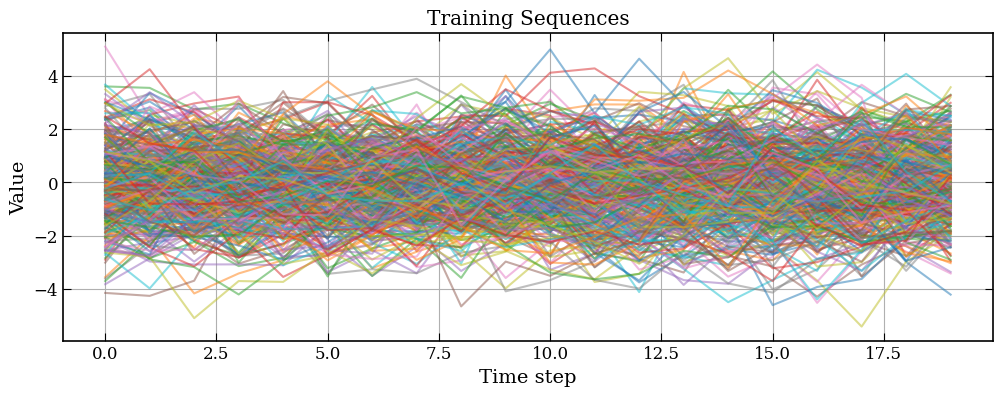

In [52]:
plt.figure(figsize=(12, 4))
plt.plot(sequences_tensor.cpu().numpy().T, alpha=0.5)
plt.title("Training Sequences")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()

In [14]:
print("Global min:", data.min())
print("Global max:", data.max())

Global min: -5.410745
Global max: 5.0896077


In [17]:
"""
Network that takes x_{<d} and returns mu_d and log(varianza_d).
We use a fixed context window (order p). The network processes
the last p values to predict the next one.
"""

class ConditionalGaussianAR(nn.Module):
    def __init__(self, input_size=10, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)  # output: mu y log_var
        )
    
    def forward(self, x_past):
        """
        x_past: tensor of the form (batch, input_size) with the last observations.
        Returns: mu, log_var (batch, 1) each.
        """
        out = self.net(x_past)          # (batch, 2)
        mu = out[:, 0:1]                # (batch, 1)
        log_var = out[:, 1:2]           # (batch, 1)
        return mu, log_var

In [15]:
"""
Calculate -log p(target | mu, var) with var = exp(log_var).
mu, log_var, target: tensors of the same shape (batch, 1)
"""

def gaussian_nll(mu, log_var, target):
    var = torch.exp(log_var) + 1e-6  
    nll = 0.5 * (torch.log(2 * torch.tensor(np.pi)) + log_var + (target - mu)**2 / var) # 
    return nll.mean() 

In [93]:
# Hyperparameters 
context_window = 10  # how many past steps we use to predict the next one
hidden_dim = 64
learning_rate = 1e-3
epochs = 1000

# Create the model and optimizer
model = ConditionalGaussianAR(input_size=context_window, hidden_dim=hidden_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [94]:
# Build (input, target) pairs from the sequences
# For each segment of length T, and each possible position d > context_window,
# we use the context_window previous values to predict  x_d.
def build_dataset(seqs, window):
    inputs = []
    targets = []
    batch, T = seqs.shape
    for i in range(batch):
        for t in range(window, T):
            inputs.append(seqs[i, t-window:t])
            targets.append(seqs[i, t:t+1])  # mantener forma (1,)
    return torch.stack(inputs), torch.stack(targets)

X_train, y_train = build_dataset(sequences_tensor, context_window)
print(f"Training pairs: {X_train.shape}, {y_train.shape}")  # (n_samples, window), (n_samples, 1)

Training pairs: torch.Size([4000, 10]), torch.Size([4000, 1])


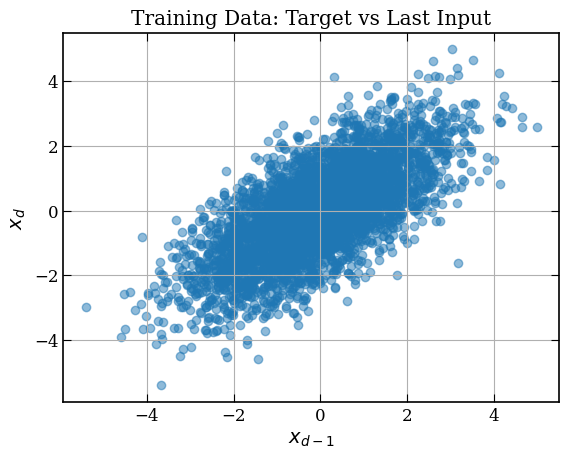

In [53]:
plt.scatter(X_train[:, -1].cpu(), y_train.cpu(), alpha=0.5)
plt.title("Training Data: Target vs Last Input")
plt.xlabel("$x_{d-1}$")
plt.ylabel("$x_d$")
plt.grid()
plt.show()

In [95]:
loss_history = []

model.train()
for epoch in range(1, epochs+1):
    optimizer.zero_grad()
    mu, log_var = model(X_train)          # (n_ejemplos, 1) cada uno
    loss = gaussian_nll(mu, log_var, y_train)
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

Epoch  20 | Loss: 1.5654
Epoch  40 | Loss: 1.4605
Epoch  60 | Loss: 1.4355
Epoch  80 | Loss: 1.4272
Epoch 100 | Loss: 1.4212
Epoch 120 | Loss: 1.4162
Epoch 140 | Loss: 1.4116
Epoch 160 | Loss: 1.4068
Epoch 180 | Loss: 1.4017
Epoch 200 | Loss: 1.3961
Epoch 220 | Loss: 1.3899
Epoch 240 | Loss: 1.3828
Epoch 260 | Loss: 1.3752
Epoch 280 | Loss: 1.3670
Epoch 300 | Loss: 1.3578
Epoch 320 | Loss: 1.3475
Epoch 340 | Loss: 1.3363
Epoch 360 | Loss: 1.3241
Epoch 380 | Loss: 1.3107
Epoch 400 | Loss: 1.2961
Epoch 420 | Loss: 1.2814
Epoch 440 | Loss: 1.2662
Epoch 460 | Loss: 1.2514
Epoch 480 | Loss: 1.2375
Epoch 500 | Loss: 1.2233
Epoch 520 | Loss: 1.2099
Epoch 540 | Loss: 1.1971
Epoch 560 | Loss: 1.1857
Epoch 580 | Loss: 1.1728
Epoch 600 | Loss: 1.1615
Epoch 620 | Loss: 1.1495
Epoch 640 | Loss: 1.1400
Epoch 660 | Loss: 1.1277
Epoch 680 | Loss: 1.1162
Epoch 700 | Loss: 1.1027
Epoch 720 | Loss: 1.0921
Epoch 740 | Loss: 1.0809
Epoch 760 | Loss: 1.0716
Epoch 780 | Loss: 1.0638
Epoch 800 | Loss: 1.0593


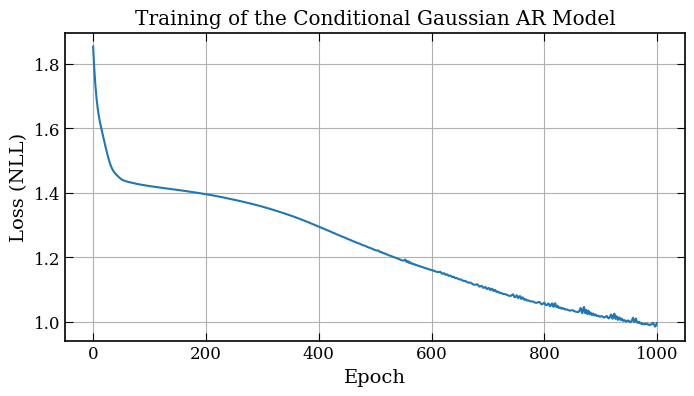

In [96]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (NLL)')
plt.title('Training of the Conditional Gaussian AR Model')
plt.grid(True)
plt.show()

In [97]:
# Veamos una predicción para un contexto de ejemplo
model.eval()
with torch.no_grad():
    # Tomamos un contexto de los datos y comparamos mu, sigma con el valor real siguiente
    ejemplo_input = X_train[0:1]  # (1, window)
    mu_pred, log_var_pred = model(ejemplo_input)
    sigma_pred = torch.exp(0.5 * log_var_pred)
    target_real = y_train[0]
    
    print(f"Contexto: {ejemplo_input.cpu().numpy().flatten()}")
    print(f"Valor real siguiente: {target_real.item():.3f}")
    print(f"μ predicha: {mu_pred.item():.3f}")
    print(f"σ predicha: {sigma_pred.item():.3f}")

Contexto: [ 0.0000000e+00 -1.2376624e+00  2.7923689e-03  8.8924551e-01
 -1.4081426e-01 -6.0632143e-02  6.4088649e-01  2.3930672e-01
  1.2404927e+00  3.2322173e+00]
Valor real siguiente: 1.477
μ predicha: 1.744
σ predicha: 0.468


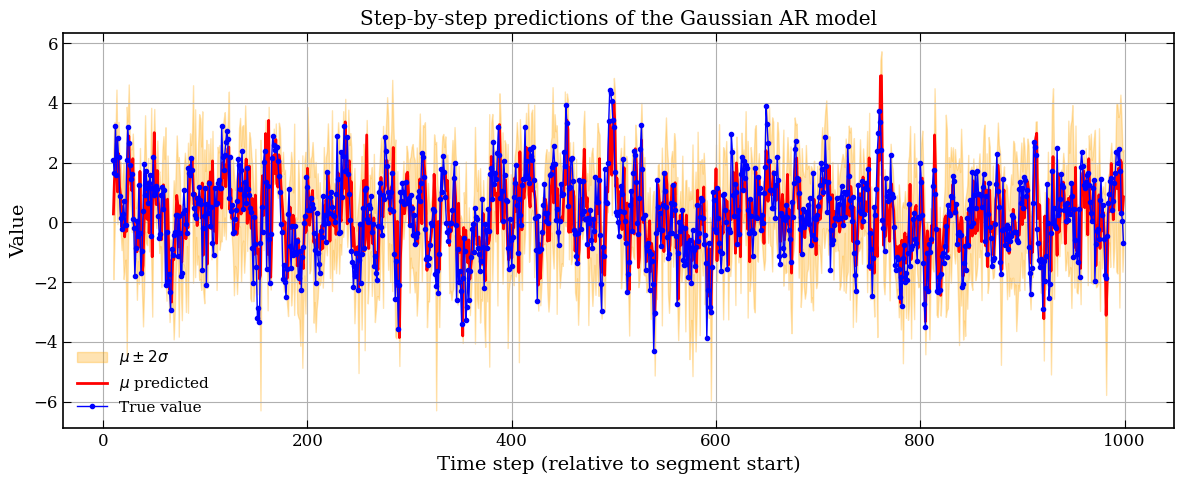

In [98]:
# choice a segment of the original series to predict
context_window = 10
segment_length = 1000  # number of steps we want to plot
start = 1000           # starting point in the full series (you can change this)
end = start + segment_length

# We use the complete 'data' series (still in numpy)
segment = data[start:end]  # 1D numpy array

# ----------------------------------------------------------------------
# 2. Set the model to evaluation mode and predict
# ----------------------------------------------------------------------
model.eval()
model.to('cpu')  # ensure it's on cpu for numpy

pred_mu = []
pred_sigma = []

with torch.no_grad():
    for i in range(context_window, len(segment)):
        # Context: the previous 5 values
        x_past = segment[i-context_window:i]
        x_past_tensor = torch.tensor(x_past, dtype=torch.float32).unsqueeze(0)  # (1, 5)
        mu, log_var = model(x_past_tensor)
        sigma = torch.exp(0.5 * log_var)  # standard deviation
        pred_mu.append(mu.item())
        pred_sigma.append(sigma.item())

pred_mu = np.array(pred_mu)
pred_sigma = np.array(pred_sigma)

# ----------------------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------------------
time_true = np.arange(context_window, len(segment))  # indices of the true predicted value
true_vals = segment[context_window:]                  # true values to predict

plt.figure(figsize=(12, 5))

# Uncertainty fill: mean ± 2*sigma (~95%)
plt.fill_between(time_true,
                 pred_mu - 2 * pred_sigma,
                 pred_mu + 2 * pred_sigma,
                 alpha=0.3, color='orange', label=r'$\mu \pm 2\sigma$')

# Predicted mean
plt.plot(time_true, pred_mu, '-', color='red', linewidth=2, label=r'$\mu$ predicted')

# True value
plt.plot(time_true, true_vals, 'o-', color='blue', markersize=3, linewidth=1, label='True value')

plt.xlabel('Time step (relative to segment start)')
plt.ylabel('Value')
plt.title('Step-by-step predictions of the Gaussian AR model')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

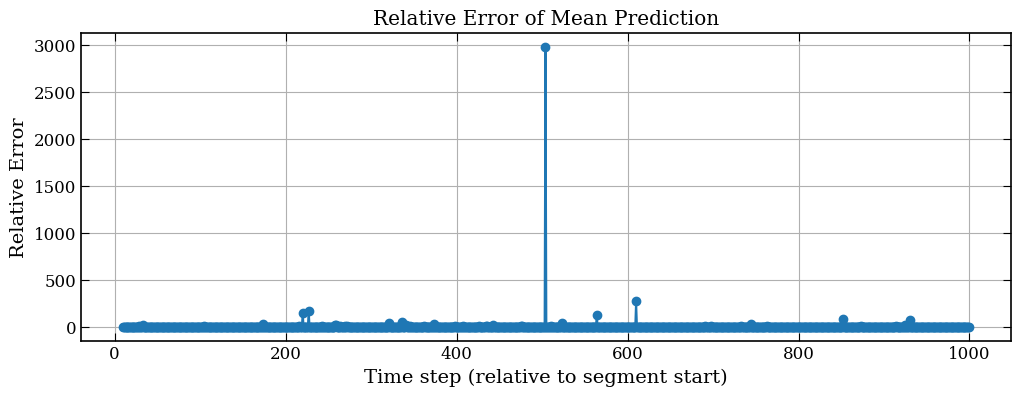

In [99]:
# relative error in mean prediction
relative_error = np.abs(pred_mu - true_vals) / (np.abs(true_vals) + 1e-10)
plt.figure(figsize=(12, 4))
plt.plot(time_true, relative_error, marker='o')
plt.title('Relative Error of Mean Prediction')
plt.xlabel('Time step (relative to segment start)')
plt.ylabel('Relative Error')
plt.grid()
plt.show()

### CASE 1:  Discrete autoregressive model
#### Vocabulary: 4 words->  "cat", "dog", "sat", "ran"
#### Word indices:            0       1      2      3

#### We generate training sentences with a hidden rule: "cat" or "dog"  tends to be followed by  "sat" or "ran"  (animals do things — a simple bigram pattern)


### Build toy training data 
#### Rule: word[0]$\in  \{0,1\}$ (animals) $\rightarrow$ word[1]$ \in \{2,3\}$ (actions)
####       word[0]$ \in \{2,3\}$ (actions) $\rightarrow$ word[1] $\in\{0,1\}$ (animals)
#### This gives the model a real pattern to learn.

In [ ]:
VOCAB_SIZE = 4   # V 
SEQ_LEN    = 2   # n = 2 (two-word sentences)

In [4]:
def make_discrete_data(n_samples=500):
    data = []
    for _ in range(n_samples):
        if np.random.rand() < 0.5:
            x1 = np.random.choice([0, 1])   # animal first
            x2 = np.random.choice([2, 3])   # then action
        else:
            x1 = np.random.choice([2, 3])   # action first
            x2 = np.random.choice([0, 1])   # then animal
        data.append([x1, x2])
    return torch.tensor(data, dtype=torch.long)

train_data_disc = make_discrete_data(500)
print(f"\nTraining sentences (first 6): {train_data_disc[:6].tolist()}")
print(f"  e.g. [0, 2] = 'cat sat',  [1, 3] = 'dog ran'\n")



Training sentences (first 6): [[1, 3], [3, 0], [2, 0], [3, 1], [0, 3], [1, 2]]
  e.g. [0, 2] = 'cat sat',  [1, 3] = 'dog ran'



Training discrete model (NLL loss)...
  Epoch 100  NLL = 2.0708
  Epoch 200  NLL = 2.0685
  Epoch 300  NLL = 2.0680
  Epoch 400  NLL = 2.0678

Learned p(x1) — probability of each first word:
  cat   0.226  █████████
  dog   0.252  ██████████
  sat   0.232  █████████
  ran   0.290  ███████████

Learned p(x2 | x1='cat') — what follows 'cat':
  cat   0.000  
  dog   0.000  
  sat   0.593  ███████████████████████
  ran   0.407  ████████████████

10 samples from the trained model:
  [dog, ran]
  [cat, ran]
  [dog, ran]
  [sat, cat]
  [sat, cat]
  [dog, sat]
  [cat, sat]
  [ran, dog]
  [dog, sat]
  [sat, cat]

CASE 2: Continuous Autoregressive Model
True relationship: x2 = 2*sin(x1) + noise

First 4 training points (x1, x2):
  (-1.430,  -1.824)
  (-1.518,  -1.804)
  (2.438,  1.461)
  (-1.503,  -1.968)

Training continuous model (Gaussian NLL)...
  Epoch  250  NLL = 0.4039
  Epoch  500  NLL = 0.1598
  Epoch  750  NLL = 0.1520
  Epoch 1000  NLL = 0.1501

Learned mu and sigma at selected x1 val

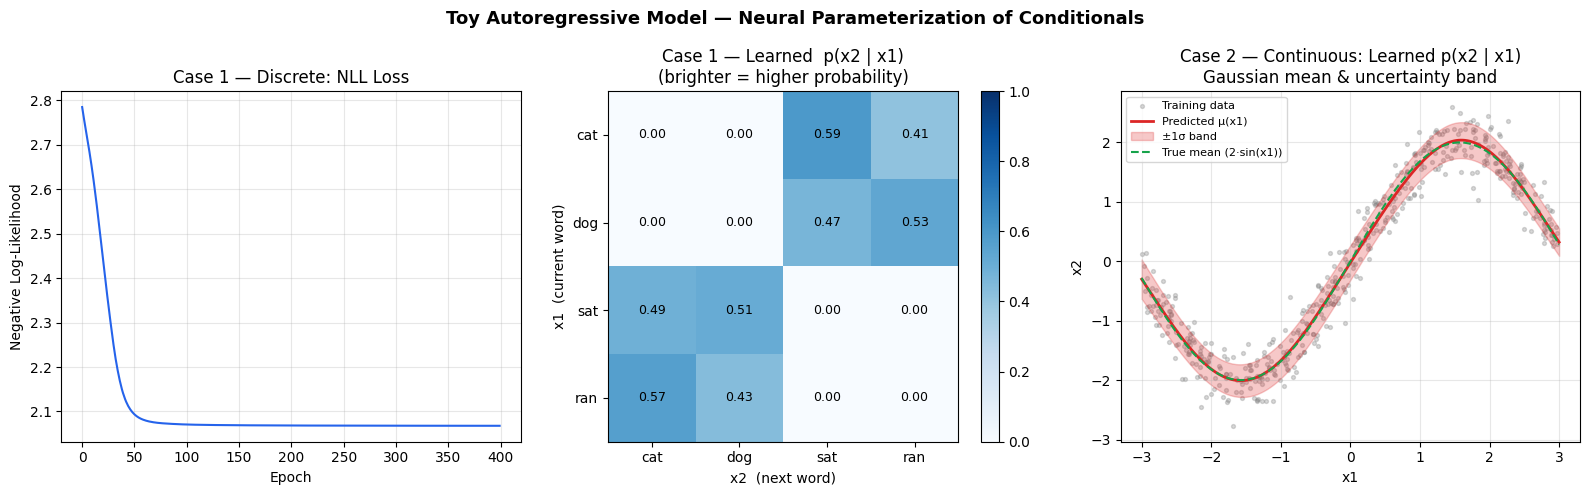

In [5]:


# ---- Model --------------------------------------------------
# The autoregressive model has two pieces:
#
#   1. p(x1):         a learnable probability vector over V classes
#                     (just V free parameters, no network needed)
#
#   2. p(x2 | x1):    a small neural network
#                     INPUT:  one-hot encoding of x1  (size V)
#                     OUTPUT: raw scores (logits) over V classes
#                             → softmax → probability over next word
#
# This directly implements eq. (ar_softmax) from the text.

class DiscreteAR(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.V = vocab_size

        # p(x1): unconstrained logits, softmax applied at eval time
        # Shape: (V,)  — one score per first word
        self.logits_x1 = nn.Parameter(torch.zeros(vocab_size))

        # p(x2 | x1): one-hidden-layer MLP
        #   Input  : one-hot(x1) → size V
        #   Hidden : 16 units with ReLU
        #   Output : V logits (one per possible x2)
        self.net_x2_given_x1 = nn.Sequential(
            nn.Linear(vocab_size, 16),
            nn.ReLU(),
            nn.Linear(16, vocab_size)
        )

    def log_prob(self, x1, x2):
        """
        Compute log p(x1, x2) = log p(x1) + log p(x2 | x1)
        for a batch of (x1, x2) pairs.
        Both x1, x2 are integer tensors of shape (batch,).
        """
        # --- log p(x1) ---
        # log_softmax turns raw logits into log-probabilities
        log_p_x1 = torch.log_softmax(self.logits_x1, dim=0)
        # Gather the log-prob of the actual x1 in each sample
        lp1 = log_p_x1[x1]                          # shape: (batch,)

        # --- log p(x2 | x1) ---
        # Encode x1 as one-hot so the network gets a fixed-size input
        x1_onehot = torch.zeros(len(x1), self.V)
        x1_onehot.scatter_(1, x1.unsqueeze(1), 1.0)  # shape: (batch, V)

        logits_x2 = self.net_x2_given_x1(x1_onehot)  # shape: (batch, V)
        log_p_x2_given_x1 = torch.log_softmax(logits_x2, dim=1)
        lp2 = log_p_x2_given_x1.gather(1, x2.unsqueeze(1)).squeeze(1)

        return lp1 + lp2   # log p(x1, x2)  — the chain rule

    def sample(self, n=1):
        """
        Ancestral sampling:
          Step 1: sample x1 ~ p(x1)
          Step 2: sample x2 ~ p(x2 | x1)
        Returns a (n, 2) integer tensor.
        """
        with torch.no_grad():
            # Step 1
            probs_x1 = torch.softmax(self.logits_x1, dim=0)
            x1 = torch.multinomial(probs_x1.expand(n, -1), num_samples=1).squeeze(1)

            # Step 2
            x1_onehot = torch.zeros(n, self.V)
            x1_onehot.scatter_(1, x1.unsqueeze(1), 1.0)
            logits_x2 = self.net_x2_given_x1(x1_onehot)
            probs_x2  = torch.softmax(logits_x2, dim=1)
            x2 = torch.multinomial(probs_x2, num_samples=1).squeeze(1)

        return torch.stack([x1, x2], dim=1)


# ---- Training -----------------------------------------------
model_disc = DiscreteAR(VOCAB_SIZE)
optimizer  = optim.Adam(model_disc.parameters(), lr=1e-2)

print("Training discrete model (NLL loss)...")
losses_disc = []
for epoch in range(400):
    x1 = train_data_disc[:, 0]
    x2 = train_data_disc[:, 1]

    # NLL loss = -mean log p(x)   (eq. ar_nll in the text)
    loss = -model_disc.log_prob(x1, x2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_disc.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"  Epoch {epoch+1:3d}  NLL = {loss.item():.4f}")


# ---- Inspect learned conditionals ---------------------------
print("\nLearned p(x1) — probability of each first word:")
with torch.no_grad():
    p_x1 = torch.softmax(model_disc.logits_x1, dim=0).numpy()
words = ["cat", "dog", "sat", "ran"]
for w, p in zip(words, p_x1):
    bar = "█" * int(p * 40)
    print(f"  {w:4s}  {p:.3f}  {bar}")

print("\nLearned p(x2 | x1='cat') — what follows 'cat':")
with torch.no_grad():
    x1_cat   = torch.zeros(1, VOCAB_SIZE); x1_cat[0, 0] = 1.0
    logits   = model_disc.net_x2_given_x1(x1_cat)
    p_x2_cat = torch.softmax(logits, dim=1).numpy()[0]
for w, p in zip(words, p_x2_cat):
    bar = "█" * int(p * 40)
    print(f"  {w:4s}  {p:.3f}  {bar}")

print("\n10 samples from the trained model:")
samples = model_disc.sample(10)
for s in samples:
    print(f"  [{words[s[0]]}, {words[s[1]]}]")


# ===========================================================
# CASE 2 — CONTINUOUS AUTOREGRESSIVE MODEL
# ===========================================================
# We model 2D data points (x1, x2).
# True distribution: x2 = 2*sin(x1) + small noise
#   so x2 depends on x1 in a nonlinear way.
#
# The model learns:
#   p(x1):       we just fit a Gaussian (mean/std estimated from data)
#   p(x2 | x1):  a neural network predicts mu(x1) and log_sigma(x1),
#                defining a Gaussian N(x2; mu(x1), sigma(x1)^2)
#                This is eq. (ar_gaussian) from the text.

print("\n" + "=" * 60)
print("CASE 2: Continuous Autoregressive Model")
print("True relationship: x2 = 2*sin(x1) + noise")
print("=" * 60)

# ---- Build toy training data --------------------------------
def make_continuous_data(n=500):
    x1 = np.random.uniform(-3, 3, size=n).astype(np.float32)
    x2 = (2.0 * np.sin(x1) + 0.3 * np.random.randn(n)).astype(np.float32)
    return torch.tensor(x1).unsqueeze(1), torch.tensor(x2).unsqueeze(1)

x1_train, x2_train = make_continuous_data(500)
print(f"\nFirst 4 training points (x1, x2):")
for i in range(4):
    print(f"  ({x1_train[i,0]:.3f},  {x2_train[i,0]:.3f})")


# ---- Model --------------------------------------------------
# p(x2 | x1) = N(x2;  mu_phi(x1),  sigma_phi(x1)^2)
#
# The network takes x1 (a single float) and outputs TWO numbers:
#   - mu:       the predicted mean of x2
#   - log_std:  the log of the predicted std dev  (we output log
#               so that std = exp(log_std) is always positive)

class ContinuousAR(nn.Module):
    def __init__(self):
        super().__init__()
        # Small MLP: 1 → 32 → 32 → 2
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 2)          # outputs [mu, log_std]
        )

    def forward(self, x1):
        """Returns (mu, std) for p(x2 | x1)."""
        out     = self.net(x1)        # shape: (batch, 2)
        mu      = out[:, 0:1]         # predicted mean
        log_std = out[:, 1:2]         # predicted log std-dev
        std     = torch.exp(log_std)  # always positive
        return mu, std

    def log_prob_x2_given_x1(self, x1, x2):
        """
        Log probability under a Gaussian:
          log N(x2; mu, sigma^2)
          = -0.5 * log(2*pi) - log(sigma) - 0.5 * ((x2-mu)/sigma)^2
        This is the Gaussian NLL from eq. (ar_gaussian).
        """
        mu, std = self.forward(x1)
        dist = torch.distributions.Normal(mu, std)
        return dist.log_prob(x2)      # shape: (batch, 1)

    def sample_x2_given_x1(self, x1):
        """Draw x2 ~ N(mu_phi(x1), sigma_phi(x1)^2)."""
        with torch.no_grad():
            mu, std = self.forward(x1)
            return torch.normal(mu, std)


# ---- Training -----------------------------------------------
model_cont = ContinuousAR()
optimizer2 = optim.Adam(model_cont.parameters(), lr=1e-3)

print("\nTraining continuous model (Gaussian NLL)...")
losses_cont = []
for epoch in range(1000):
    log_p = model_cont.log_prob_x2_given_x1(x1_train, x2_train)
    loss  = -log_p.mean()

    optimizer2.zero_grad()
    loss.backward()
    optimizer2.step()

    losses_cont.append(loss.item())
    if (epoch + 1) % 250 == 0:
        print(f"  Epoch {epoch+1:4d}  NLL = {loss.item():.4f}")


# ---- Inspect learned conditional ----------------------------
print("\nLearned mu and sigma at selected x1 values:")
test_x1 = torch.tensor([[-2.5], [-1.0], [0.0], [1.0], [2.5]])
with torch.no_grad():
    mu_pred, std_pred = model_cont(test_x1)
true_mu = 2.0 * np.sin(test_x1.numpy())

print(f"  {'x1':>6}  {'true mu':>8}  {'pred mu':>8}  {'pred std':>9}")
for i in range(len(test_x1)):
    print(f"  {test_x1[i,0]:6.2f}  {true_mu[i,0]:8.3f}  "
          f"{mu_pred[i,0].item():8.3f}  {std_pred[i,0].item():9.4f}")


# ===========================================================
# VISUALIZE BOTH CASES
# ===========================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Toy Autoregressive Model — Neural Parameterization of Conditionals",
             fontsize=13, fontweight="bold")

# --- Plot 1: Discrete training loss -------------------------
ax = axes[0]
ax.plot(losses_disc, color="#2563EB", linewidth=1.5)
ax.set_title("Case 1 — Discrete: NLL Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative Log-Likelihood")
ax.grid(alpha=0.3)

# --- Plot 2: Learned p(x2 | x1) for each x1 (discrete) -----
ax = axes[1]
cond_probs = np.zeros((VOCAB_SIZE, VOCAB_SIZE))
with torch.no_grad():
    for i in range(VOCAB_SIZE):
        x1_oh = torch.zeros(1, VOCAB_SIZE); x1_oh[0, i] = 1.0
        logits = model_disc.net_x2_given_x1(x1_oh)
        cond_probs[i] = torch.softmax(logits, dim=1).numpy()[0]

im = ax.imshow(cond_probs, vmin=0, vmax=1, cmap="Blues")
ax.set_xticks(range(VOCAB_SIZE)); ax.set_xticklabels(words)
ax.set_yticks(range(VOCAB_SIZE)); ax.set_yticklabels(words)
ax.set_xlabel("x2  (next word)")
ax.set_ylabel("x1  (current word)")
ax.set_title("Case 1 — Learned  p(x2 | x1)\n(brighter = higher probability)")
for i in range(VOCAB_SIZE):
    for j in range(VOCAB_SIZE):
        ax.text(j, i, f"{cond_probs[i,j]:.2f}", ha="center", va="center",
                fontsize=9, color="black" if cond_probs[i,j] < 0.6 else "white")
plt.colorbar(im, ax=ax)

# --- Plot 3: Continuous model fit ----------------------------
ax = axes[2]
x1_np = x1_train.numpy().flatten()
x2_np = x2_train.numpy().flatten()
ax.scatter(x1_np, x2_np, s=8, alpha=0.3, color="gray", label="Training data")

x1_grid = torch.linspace(-3, 3, 200).unsqueeze(1)
with torch.no_grad():
    mu_grid, std_grid = model_cont(x1_grid)
mu_grid  = mu_grid.numpy().flatten()
std_grid = std_grid.numpy().flatten()
x1_grid  = x1_grid.numpy().flatten()

ax.plot(x1_grid, mu_grid, color="#DC2626", linewidth=2, label="Predicted μ(x1)")
ax.fill_between(x1_grid, mu_grid - std_grid, mu_grid + std_grid,
                alpha=0.25, color="#DC2626", label="±1σ band")
ax.plot(x1_grid, 2 * np.sin(x1_grid), color="#16A34A", linewidth=1.5,
        linestyle="--", label="True mean (2·sin(x1))")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Case 2 — Continuous: Learned p(x2 | x1)\nGaussian mean & uncertainty band")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/autoregressive_toy.png", dpi=150, bbox_inches="tight")
plt.show()